# PEMS08 Feature Correlation and ML Analysis

This notebook performs comprehensive correlation analysis and machine learning predictions on PEMS08 data features.

## Objectives:
1. Load PEMS08.npz data with three features
2. Calculate various correlation metrics (Pearson, Spearman, Kendall, Distance, Mutual Information)
3. Train multiple ML models (XGBoost, CatBoost, LightGBM, etc.) to predict one feature from another
4. Evaluate and visualize actual vs predicted results

## 1. Import Required Libraries

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import pearsonr, spearmanr, kendalltau
import warnings
warnings.filterwarnings('ignore')

# Machine Learning libraries
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.dummy import DummyRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.feature_selection import mutual_info_regression

# Gradient Boosting Models
import xgboost as xgb
import lightgbm as lgb
# CatBoost may have binary incompatibility in this environment; import optionally
try:
    from catboost import CatBoostRegressor
    catboost_available = True
except Exception as e:
    print(f"CatBoost import failed: {e}")
    CatBoostRegressor = None
    catboost_available = False

# Additional utilities
import joblib
import os
from datetime import datetime
import time

# Set random seed for reproducibility
np.random.seed(42)

# Plot settings
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
%matplotlib inline

print("All libraries imported successfully!")

CatBoost import failed: numpy.ndarray size changed, may indicate binary incompatibility. Expected 96 from C header, got 88 from PyObject
All libraries imported successfully!


## 2. Load and Inspect PEMS08 Data

In [6]:
# Load PEMS08 data
data_path = '/home/jatin/contrast/ST-SSL/data/raw/PEMS08/PEMS08.npz'
data_npz = np.load(data_path)

# List all keys in the npz file
print("Keys in PEMS08.npz:")
print(list(data_npz.keys()))
print("\n" + "="*80 + "\n")

# Inspect each array
for key in data_npz.keys():
    arr = data_npz[key]
    print(f"Key: {key}")
    print(f"  Shape: {arr.shape}")
    print(f"  Dtype: {arr.dtype}")
    print(f"  Min: {arr.min():.4f}, Max: {arr.max():.4f}, Mean: {arr.mean():.4f}")
    print()

Keys in PEMS08.npz:
['data']


Key: data
  Shape: (17856, 170, 3)
  Dtype: float64
  Min: 0.0000, Max: 1147.0000, Mean: 98.1696



In [10]:
# Extract the main data array (typically 'data' key)
# The data is usually in shape (num_samples, num_nodes, num_features)
data_array = data_npz['data']
print(f"Data array shape: {data_array.shape}")
print(f"Interpretation: ({data_array.shape[0]} timesteps, {data_array.shape[1]} nodes/sensors, {data_array.shape[2]} features)")

# Extract three features by taking the mean across all nodes for each feature
# This gives us time series for each feature
feature_1 = data_array[:, :, 0].mean(axis=1)  # Average of feature 1 across all nodes
feature_2 = data_array[:, :, 1].mean(axis=1)  # Average of feature 2 across all nodes
feature_3 = data_array[:, :, 2].mean(axis=1)  # Average of feature 3 across all nodes

# Create DataFrame
df = pd.DataFrame({
    'Feature_1': feature_1,
    'Feature_2': feature_2,
    'Feature_3': feature_3
})

print("\n" + "="*80)
print("DataFrame created with 3 features (averaged across all nodes)")
print("="*80 + "\n")
print(df.head(10))
print(f"\nDataFrame shape: {df.shape}")
print(f"\nData types:\n{df.dtypes}")
print(f"\nMissing values:\n{df.isnull().sum()}")
print(f"\nBasic statistics:\n{df.describe()}")

Data array shape: (17856, 170, 3)
Interpretation: (17856 timesteps, 170 nodes/sensors, 3 features)

DataFrame created with 3 features (averaged across all nodes)

    Feature_1  Feature_2  Feature_3
0  111.682353   0.034141  67.379412
1  110.423529   0.032504  66.767059
2  109.829412   0.031345  66.550000
3  107.347059   0.031569  66.246471
4  103.335294   0.030611  66.138824
5   98.264706   0.029248  65.985294
6   95.170588   0.028404  65.994118
7   94.564706   0.028066  66.042941
8   93.252941   0.027717  65.937059
9   91.894118   0.027908  65.921765

DataFrame shape: (17856, 3)

Data types:
Feature_1    float64
Feature_2    float64
Feature_3    float64
dtype: object

Missing values:
Feature_1    0
Feature_2    0
Feature_3    0
dtype: int64

Basic statistics:
          Feature_1     Feature_2     Feature_3
count  17856.000000  17856.000000  17856.000000
mean     230.680694      0.065071     63.762996
std       91.938854      0.028069      2.783302
min       56.105882      0.014471   

## 3. Visualize Features and Distributions

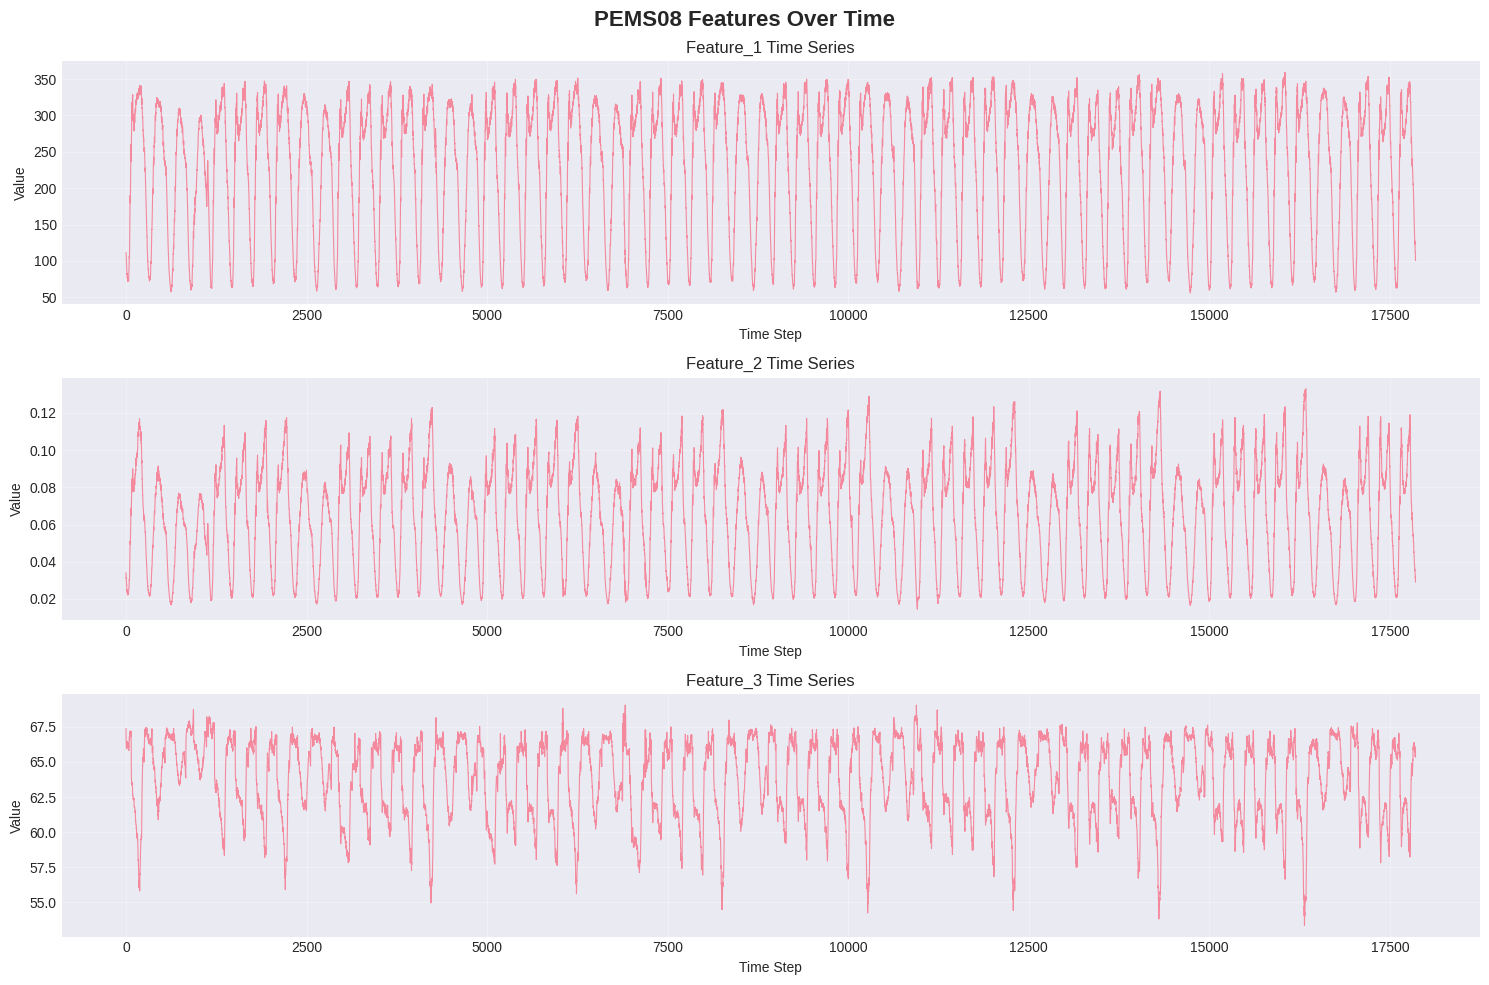

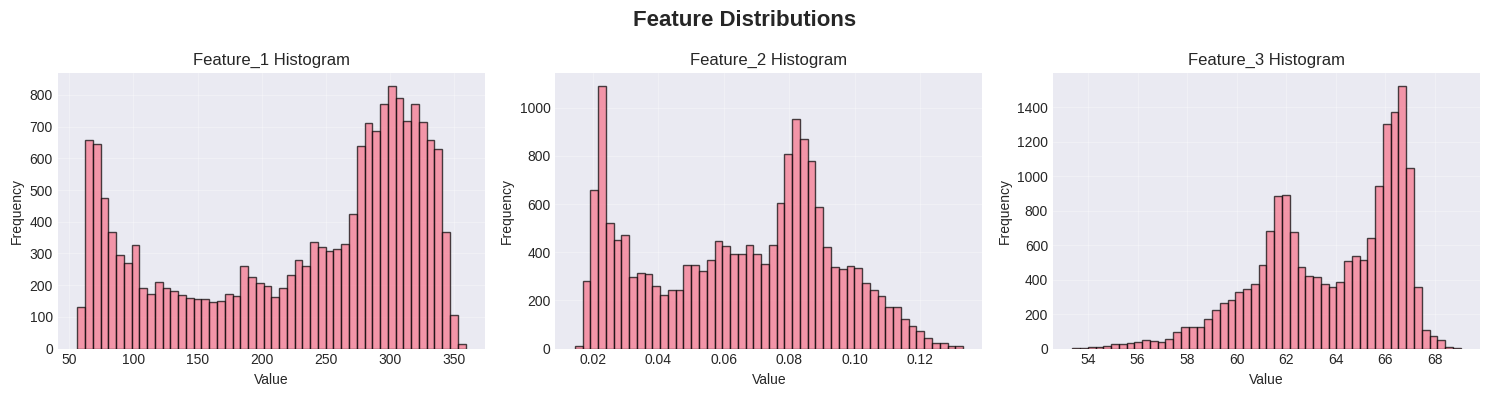

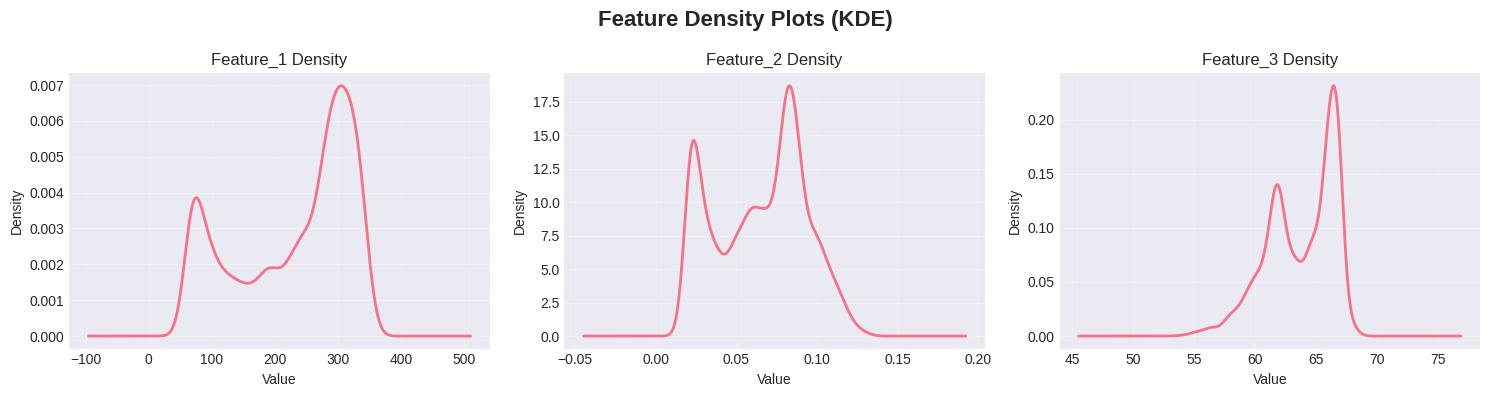

In [12]:
# Time series plots
fig, axes = plt.subplots(3, 1, figsize=(15, 10))
fig.suptitle('PEMS08 Features Over Time', fontsize=16, fontweight='bold')

for idx, col in enumerate(df.columns):
    axes[idx].plot(df[col], linewidth=0.8, alpha=0.8)
    axes[idx].set_title(f'{col} Time Series', fontsize=12)
    axes[idx].set_xlabel('Time Step')
    axes[idx].set_ylabel('Value')
    axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Distribution plots
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Feature Distributions', fontsize=16, fontweight='bold')

for idx, col in enumerate(df.columns):
    axes[idx].hist(df[col], bins=50, alpha=0.7, edgecolor='black')
    axes[idx].set_title(f'{col} Histogram')
    axes[idx].set_xlabel('Value')
    axes[idx].set_ylabel('Frequency')
    axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# KDE plots
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Feature Density Plots (KDE)', fontsize=16, fontweight='bold')

for idx, col in enumerate(df.columns):
    df[col].plot(kind='kde', ax=axes[idx], linewidth=2)
    axes[idx].set_title(f'{col} Density')
    axes[idx].set_xlabel('Value')
    axes[idx].set_ylabel('Density')
    axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

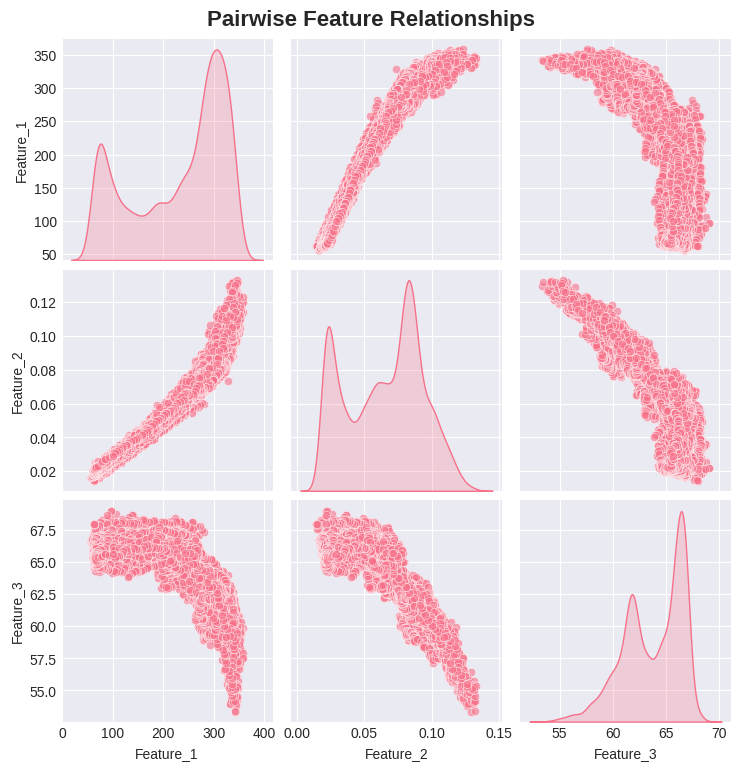

In [17]:
# Pairwise scatter plots
sns.pairplot(df, diag_kind='kde', plot_kws={'alpha': 0.6})
plt.suptitle('Pairwise Feature Relationships', y=1.02, fontsize=16, fontweight='bold')
plt.show()

## 4. Comprehensive Correlation Analysis

### Pearson Correlation Formula:
$$r = \frac{\sum_i (x_i - \bar{x})(y_i - \bar{y})}{\sqrt{\sum_i (x_i - \bar{x})^2}\sqrt{\sum_i (y_i - \bar{y})^2}}$$

We'll compute multiple correlation measures to understand the relationships between features from different perspectives.

In [9]:
# Function to calculate distance correlation
def distance_correlation(x, y):
    """Calculate distance correlation between two arrays"""
    n = len(x)
    a = np.abs(np.subtract.outer(x, x))
    b = np.abs(np.subtract.outer(y, y))
    
    A = a - a.mean(axis=0)[None, :] - a.mean(axis=1)[:, None] + a.mean()
    B = b - b.mean(axis=0)[None, :] - b.mean(axis=1)[:, None] + b.mean()
    
    dcov2_xy = (A * B).sum() / n**2
    dcov2_xx = (A * A).sum() / n**2
    dcov2_yy = (B * B).sum() / n**2
    
    dcor = np.sqrt(dcov2_xy) / np.sqrt(np.sqrt(dcov2_xx) * np.sqrt(dcov2_yy))
    return dcor

# Function to calculate partial correlation
def partial_correlation(df, x_col, y_col, z_col):
    """Calculate partial correlation between x and y controlling for z"""
    # Residuals of x regressed on z
    lr_xz = LinearRegression()
    lr_xz.fit(df[[z_col]], df[x_col])
    resid_x = df[x_col] - lr_xz.predict(df[[z_col]])
    
    # Residuals of y regressed on z
    lr_yz = LinearRegression()
    lr_yz.fit(df[[z_col]], df[y_col])
    resid_y = df[y_col] - lr_yz.predict(df[[z_col]])
    
    # Correlation of residuals
    return pearsonr(resid_x, resid_y)[0]

print("Correlation calculation functions defined successfully!")

Correlation calculation functions defined successfully!


In [11]:
# Calculate all correlation measures for all feature pairs
correlation_results = []

features = df.columns.tolist()

for i, feat1 in enumerate(features):
    for j, feat2 in enumerate(features):
        if i < j:  # Only calculate for unique pairs
            # Pearson correlation
            pearson_r, pearson_p = pearsonr(df[feat1], df[feat2])
            
            # Spearman correlation
            spearman_r, spearman_p = spearmanr(df[feat1], df[feat2])
            
            # Kendall Tau correlation
            kendall_tau, kendall_p = kendalltau(df[feat1], df[feat2])
            
            # Distance correlation
            dcor = distance_correlation(df[feat1].values, df[feat2].values)
            
            # Mutual information
            mi = mutual_info_regression(df[[feat1]], df[feat2], random_state=42)[0]
            
            # Partial correlation (controlling for the third feature)
            third_feat = [f for f in features if f not in [feat1, feat2]][0]
            partial_r = partial_correlation(df, feat1, feat2, third_feat)
            
            correlation_results.append({
                'Feature_Pair': f'{feat1} vs {feat2}',
                'Pearson_r': pearson_r,
                'Pearson_p': pearson_p,
                'Spearman_r': spearman_r,
                'Spearman_p': spearman_p,
                'Kendall_tau': kendall_tau,
                'Kendall_p': kendall_p,
                'Distance_Corr': dcor,
                'Mutual_Info': mi,
                f'Partial_r (ctrl {third_feat})': partial_r
            })

# Create correlation results DataFrame
corr_df = pd.DataFrame(correlation_results)
print("="*100)
print("COMPREHENSIVE CORRELATION ANALYSIS")
print("="*100)
print(corr_df.to_string(index=False))
print("\n" + "="*100)

COMPREHENSIVE CORRELATION ANALYSIS
          Feature_Pair  Pearson_r  Pearson_p  Spearman_r  Spearman_p  Kendall_tau  Kendall_p  Distance_Corr  Mutual_Info  Partial_r (ctrl Feature_3)  Partial_r (ctrl Feature_2)  Partial_r (ctrl Feature_1)
Feature_1 vs Feature_2   0.971281        0.0    0.979480         0.0     0.887205        0.0       0.980967     1.958595                    0.954473                         NaN                         NaN
Feature_1 vs Feature_3  -0.797442        0.0   -0.860429         0.0    -0.648261        0.0       0.840124     0.901408                         NaN                    0.654028                         NaN
Feature_2 vs Feature_3  -0.893097        0.0   -0.894437         0.0    -0.714577        0.0       0.902209     1.172719                         NaN                         NaN                   -0.825783



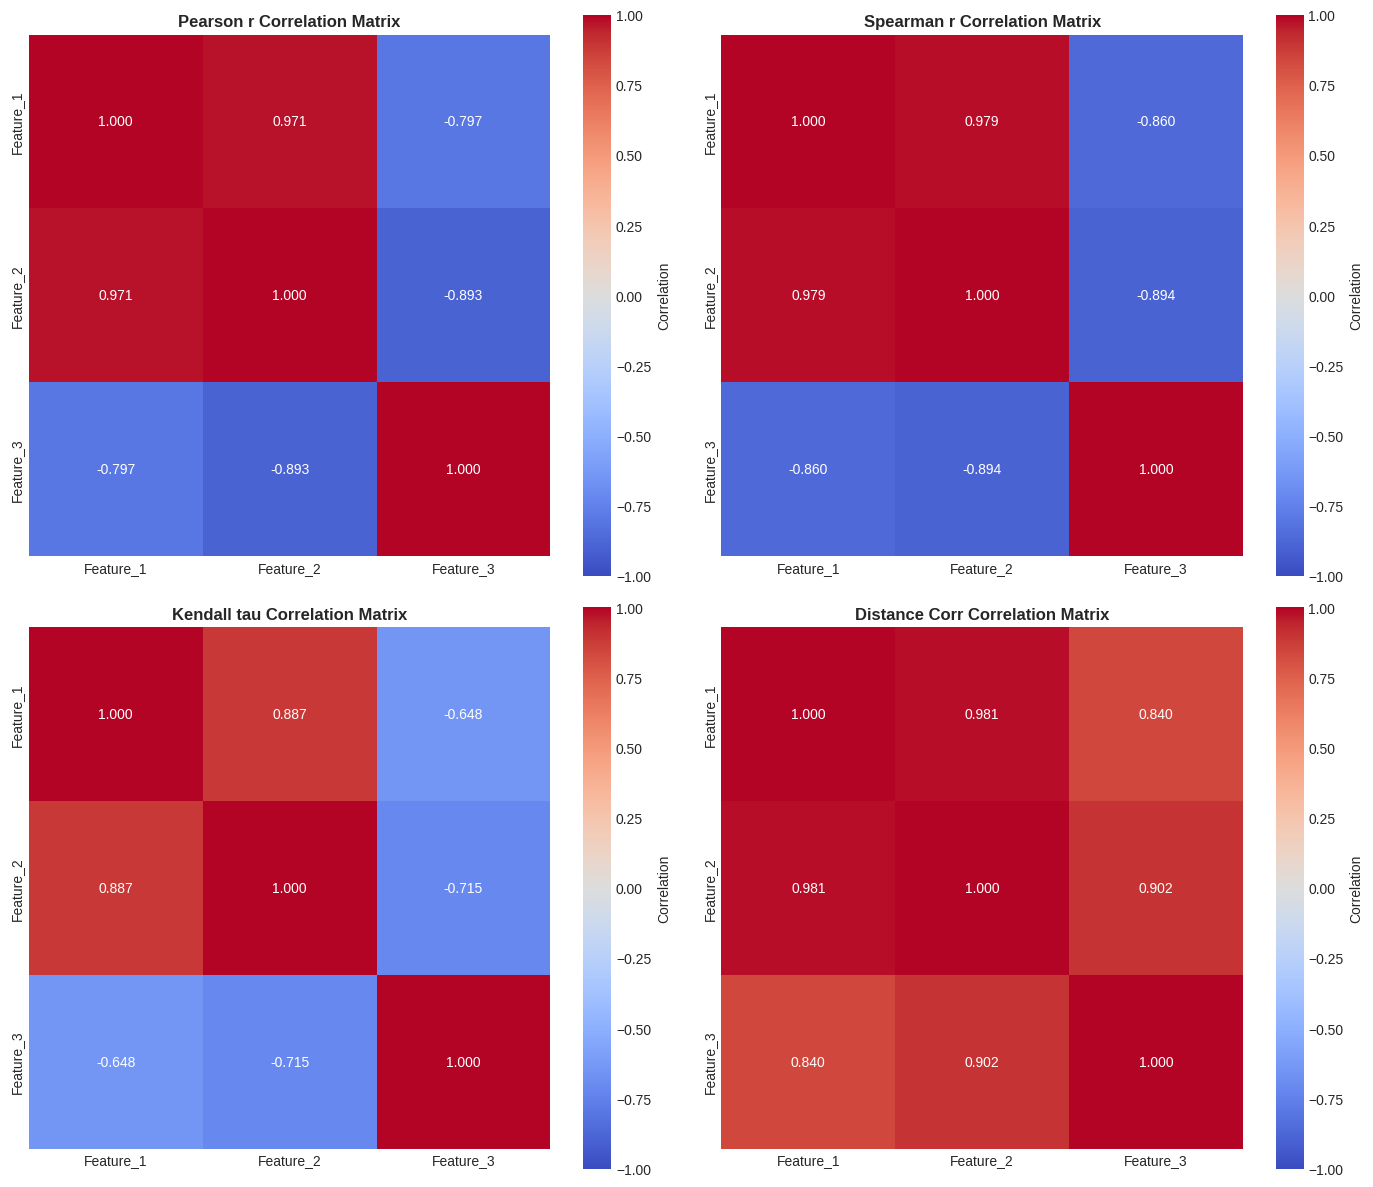

In [13]:
# Visualize correlation matrices
correlation_methods = ['Pearson_r', 'Spearman_r', 'Kendall_tau', 'Distance_Corr']

fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.flatten()

for idx, method in enumerate(correlation_methods):
    # Create correlation matrix
    corr_matrix = pd.DataFrame(index=features, columns=features, dtype=float)
    for i in features:
        for j in features:
            if i == j:
                corr_matrix.loc[i, j] = 1.0
            else:
                # Find the correlation value
                mask1 = corr_df['Feature_Pair'] == f'{i} vs {j}'
                mask2 = corr_df['Feature_Pair'] == f'{j} vs {i}'
                if mask1.any():
                    corr_matrix.loc[i, j] = corr_df.loc[mask1, method].values[0]
                elif mask2.any():
                    corr_matrix.loc[i, j] = corr_df.loc[mask2, method].values[0]
    
    # Plot heatmap
    sns.heatmap(corr_matrix.astype(float), annot=True, fmt='.3f', cmap='coolwarm', 
                center=0, vmin=-1, vmax=1, square=True, ax=axes[idx],
                cbar_kws={'label': 'Correlation'})
    axes[idx].set_title(f'{method.replace("_", " ")} Correlation Matrix', 
                        fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

## 5. Machine Learning: Feature-to-Feature Prediction

Now we'll train multiple ML models to predict one feature from another. We'll test all possible directional pairs:
- Feature_1 → Feature_2
- Feature_1 → Feature_3
- Feature_2 → Feature_1
- Feature_2 → Feature_3
- Feature_3 → Feature_1
- Feature_3 → Feature_2

In [14]:
# Create all possible feature pairs for prediction
feature_pairs = []
for feat1 in features:
    for feat2 in features:
        if feat1 != feat2:
            feature_pairs.append((feat1, feat2))

print(f"Total prediction tasks: {len(feature_pairs)}")
print("Feature pairs (Input → Output):")
for i, (inp, out) in enumerate(feature_pairs, 1):
    print(f"  {i}. {inp} → {out}")

Total prediction tasks: 6
Feature pairs (Input → Output):
  1. Feature_1 → Feature_2
  2. Feature_1 → Feature_3
  3. Feature_2 → Feature_1
  4. Feature_2 → Feature_3
  5. Feature_3 → Feature_1
  6. Feature_3 → Feature_2


In [15]:
# Prepare storage for results
results = []
predictions_storage = {}

# Create results directory
results_dir = '/home/jatin/contrast/ST-SSL/notebook/ml_results_pems08'
os.makedirs(results_dir, exist_ok=True)
print(f"Results will be saved to: {results_dir}")

Results will be saved to: /home/jatin/contrast/ST-SSL/notebook/ml_results_pems08


In [19]:
# Train and evaluate models for each feature pair
trained_models = {}  # store trained model objects
scalers = {}         # store scalers per pair

for input_feature, output_feature in feature_pairs:
    print(f"\n{'='*80}")
    print(f"Training models: {input_feature} → {output_feature}")
    print('='*80)
    
    # Prepare data
    X = df[[input_feature]].values
    y = df[output_feature].values
    
    # Split data
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, shuffle=True
    )
    
    # Scale features
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    scalers[(input_feature, output_feature)] = scaler
    
    # Define models (include CatBoost only if available)
    models = {
        'Linear Regression': LinearRegression(),
        'Ridge Regression': Ridge(alpha=1.0),
        'XGBoost': xgb.XGBRegressor(
            n_estimators=100, 
            learning_rate=0.1, 
            max_depth=5, 
            random_state=42,
            verbosity=0
        ),
        'LightGBM': lgb.LGBMRegressor(
            n_estimators=100, 
            learning_rate=0.1, 
            max_depth=5, 
            random_state=42,
            verbosity=-1
        )
    }
    if catboost_available:
        models['CatBoost'] = CatBoostRegressor(
            iterations=100,
            learning_rate=0.1,
            depth=5,
            random_state=42,
            verbose=0
        )
    else:
        print("  Note: CatBoost not available in this environment; skipping CatBoost model.")
    
    # Train and evaluate each model
    for model_name, model in models.items():
        start_time = time.time()
        
        # Train model
        model.fit(X_train_scaled, y_train)
        
        # Predict
        y_pred_train = model.predict(X_train_scaled)
        y_pred_test = model.predict(X_test_scaled)
        
        train_time = time.time() - start_time
        
        # Calculate metrics
        mae = mean_absolute_error(y_test, y_pred_test)
        mse = mean_squared_error(y_test, y_pred_test)
        rmse = np.sqrt(mse)
        r2 = r2_score(y_test, y_pred_test)
        
        # Store results
        results.append({
            'Input_Feature': input_feature,
            'Output_Feature': output_feature,
            'Pair': f'{input_feature} → {output_feature}',
            'Model': model_name,
            'MAE': mae,
            'MSE': mse,
            'RMSE': rmse,
            'R2': r2,
            'Train_Time': train_time
        })
        
        # Store model object and predictions for visualization
        key = f"{input_feature}_{output_feature}_{model_name}"
        trained_models[(input_feature, output_feature, model_name)] = model
        predictions_storage[key] = {
            'y_test': y_test,
            'y_pred': y_pred_test,
            'X_test': X_test
        }
        
        print(f"  {model_name:20s} | MAE: {mae:.4f} | RMSE: {rmse:.4f} | R²: {r2:.4f} | Time: {train_time:.2f}s")

print("\n" + "="*80)
print("All models trained for all pairs (skip noted models if unavailable)!")
print("="*80)


Training models: Feature_1 → Feature_2
  Note: CatBoost not available in this environment; skipping CatBoost model.
  Linear Regression    | MAE: 0.0049 | RMSE: 0.0064 | R²: 0.9454 | Time: 0.00s
  Ridge Regression     | MAE: 0.0049 | RMSE: 0.0064 | R²: 0.9454 | Time: 0.00s
  XGBoost              | MAE: 0.0034 | RMSE: 0.0047 | R²: 0.9708 | Time: 1.07s
  LightGBM             | MAE: 0.0034 | RMSE: 0.0047 | R²: 0.9707 | Time: 0.27s

Training models: Feature_1 → Feature_3
  Note: CatBoost not available in this environment; skipping CatBoost model.
  Linear Regression    | MAE: 1.3305 | RMSE: 1.6408 | R²: 0.6372 | Time: 0.00s
  Ridge Regression     | MAE: 1.3305 | RMSE: 1.6408 | R²: 0.6372 | Time: 0.00s
  XGBoost              | MAE: 0.8325 | RMSE: 1.1033 | R²: 0.8360 | Time: 1.00s
  LightGBM             | MAE: 0.8309 | RMSE: 1.1008 | R²: 0.8367 | Time: 0.14s

Training models: Feature_2 → Feature_1
  Note: CatBoost not available in this environment; skipping CatBoost model.
  Linear Regressi

## 9. Custom Deep Learning Model (PyTorch) — Predict Feature_1 from Feature_3

We'll train a small PyTorch MLP that takes Feature_3 as input and predicts Feature_1. We'll scale inputs and targets, use a validation split, implement early stopping, and save the trained model and scalers.

Using device: cuda
Epoch 001 | Train Loss: 0.377600 | Val Loss: 0.265140 | Best Val: 0.265140
Epoch 010 | Train Loss: 0.265536 | Val Loss: 0.258745 | Best Val: 0.254528
Epoch 020 | Train Loss: 0.265380 | Val Loss: 0.254368 | Best Val: 0.253376
Early stopping at epoch 26. Best val loss: 0.253376

PyTorch MLP Test Metrics:
MAE: 33.2528 | RMSE: 45.3300 | R²: 0.7515
Saved PyTorch model: /home/jatin/contrast/ST-SSL/notebook/ml_results_pems08/models/Feature_3_to_Feature_1__PyTorch_MLP.pt


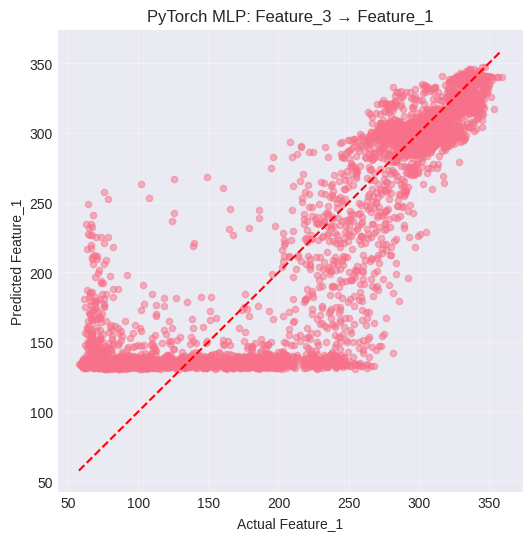

In [26]:
# PyTorch MLP for Feature_3 -> Feature_1
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Prepare data (Feature_3 -> Feature_1)
X = df[['Feature_3']].values.astype(np.float32)
y = df['Feature_1'].values.astype(np.float32).reshape(-1, 1)

# Scale X and y
scaler_X = StandardScaler()
scaler_y = StandardScaler()
X_scaled = scaler_X.fit_transform(X)
y_scaled = scaler_y.fit_transform(y)

# Train/val/test split
X_train_full, X_test, y_train_full, y_test = train_test_split(X_scaled, y_scaled, test_size=0.2, random_state=42, shuffle=True)
X_train, X_val, y_train, y_val = train_test_split(X_train_full, y_train_full, test_size=0.1, random_state=42)

# Create DataLoaders
batch_size = 64
train_ds = TensorDataset(torch.from_numpy(X_train), torch.from_numpy(y_train))
val_ds = TensorDataset(torch.from_numpy(X_val), torch.from_numpy(y_val))
test_ds = TensorDataset(torch.from_numpy(X_test), torch.from_numpy(y_test))

train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False)

# Define MLP model
class MLPRegressor(nn.Module):
    def __init__(self, input_dim=1, hidden_dims=[64, 32], dropout=0.1):
        super().__init__()
        layers = []
        in_dim = input_dim
        for h in hidden_dims:
            layers.append(nn.Linear(in_dim, h))
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(dropout))
            in_dim = h
        layers.append(nn.Linear(in_dim, 1))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

# Instantiate model, loss, optimizer
model = MLPRegressor(input_dim=1, hidden_dims=[64, 32], dropout=0.1).to(device)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

# Training loop with early stopping
n_epochs = 200
best_val_loss = np.inf
patience = 15
patience_counter = 0

for epoch in range(1, n_epochs + 1):
    model.train()
    train_losses = []
    for xb, yb in train_loader:
        xb = xb.to(device)
        yb = yb.to(device)
        optimizer.zero_grad()
        y_pred = model(xb)
        loss = criterion(y_pred, yb)
        loss.backward()
        optimizer.step()
        train_losses.append(loss.item())

    # validation
    model.eval()
    val_losses = []
    with torch.no_grad():
        for xb, yb in val_loader:
            xb = xb.to(device)
            yb = yb.to(device)
            y_pred = model(xb)
            loss = criterion(y_pred, yb)
            val_losses.append(loss.item())

    train_loss = np.mean(train_losses)
    val_loss = np.mean(val_losses)

    if val_loss < best_val_loss - 1e-6:
        best_val_loss = val_loss
        patience_counter = 0
        # save best model weights
        best_state = {k: v.cpu() for k, v in model.state_dict().items()}
    else:
        patience_counter += 1

    if epoch % 10 == 0 or epoch == 1:
        print(f"Epoch {epoch:03d} | Train Loss: {train_loss:.6f} | Val Loss: {val_loss:.6f} | Best Val: {best_val_loss:.6f}")

    if patience_counter >= patience:
        print(f"Early stopping at epoch {epoch}. Best val loss: {best_val_loss:.6f}")
        break

# Load best weights
model.load_state_dict(best_state)

# Evaluate on test set
model.eval()
all_preds = []
all_targets = []
with torch.no_grad():
    for xb, yb in test_loader:
        xb = xb.to(device)
        yb = yb.to(device)
        yp = model(xb).cpu().numpy()
        all_preds.append(yp)
        all_targets.append(yb.cpu().numpy())

y_pred_scaled = np.vstack(all_preds)
y_true_scaled = np.vstack(all_targets)

# Inverse transform to original scale
y_pred = scaler_y.inverse_transform(y_pred_scaled)
y_true = scaler_y.inverse_transform(y_true_scaled)

mae_dl = mean_absolute_error(y_true, y_pred)
mse_dl = mean_squared_error(y_true, y_pred)
rmse_dl = np.sqrt(mse_dl)
r2_dl = r2_score(y_true, y_pred)

print('\nPyTorch MLP Test Metrics:')
print(f"MAE: {mae_dl:.4f} | RMSE: {rmse_dl:.4f} | R²: {r2_dl:.4f}")

# Store results
results.append({
    'Input_Feature': 'Feature_3',
    'Output_Feature': 'Feature_1',
    'Pair': 'Feature_3 → Feature_1',
    'Model': 'PyTorch_MLP',
    'MAE': mae_dl,
    'MSE': mse_dl,
    'RMSE': rmse_dl,
    'R2': r2_dl,
    'Train_Time': None
})

# Store trained model and scaler
trained_models[('Feature_3', 'Feature_1', 'PyTorch_MLP')] = model
scalers[('Feature_3', 'Feature_1')] = (scaler_X, scaler_y)  # reuse variable names; note scaler_X was for other usage

# Save PyTorch model state dict and scalers
pt_model_path = os.path.join(models_dir, 'Feature_3_to_Feature_1__PyTorch_MLP.pt')
torch.save(model.state_dict(), pt_model_path)
joblib.dump((scaler_X, scaler_y), os.path.join(models_dir, 'Feature_3_to_Feature_1__PyTorch_MLP_scalers.joblib'))
print(f"Saved PyTorch model: {pt_model_path}")

# Save predictions for visualization
predictions_storage['Feature_3_Feature_1_PyTorch_MLP'] = {
    'y_test': y_true.flatten(),
    'y_pred': y_pred.flatten(),
    'X_test': X_test  # scaled
}

# Plot actual vs predicted
plt.figure(figsize=(6,6))
plt.scatter(y_true, y_pred, alpha=0.5, s=20)
mn = min(y_true.min(), y_pred.min())
mx = max(y_true.max(), y_pred.max())
plt.plot([mn, mx], [mn, mx], 'r--')
plt.xlabel('Actual Feature_1')
plt.ylabel('Predicted Feature_1')
plt.title('PyTorch MLP: Feature_3 → Feature_1')
plt.grid(alpha=0.3)
plt.show()

## 6. Results Analysis

In [21]:
# Create results DataFrame
results_df = pd.DataFrame(results)

# Sort by R2 score
results_df_sorted = results_df.sort_values(['Pair', 'R2'], ascending=[True, False])

print("="*120)
print("COMPREHENSIVE MODEL EVALUATION RESULTS")
print("="*120)
print(results_df_sorted.to_string(index=False))
print("\n" + "="*120)

# Save results to CSV
results_csv_path = os.path.join(results_dir, 'model_results.csv')
results_df.to_csv(results_csv_path, index=False)
print(f"\nResults saved to: {results_csv_path}")

COMPREHENSIVE MODEL EVALUATION RESULTS
Input_Feature Output_Feature                  Pair             Model       MAE         MSE      RMSE       R2  Train_Time
    Feature_1      Feature_2 Feature_1 → Feature_2           XGBoost  0.003390    0.000022  0.004712 0.970778    1.070486
    Feature_1      Feature_2 Feature_1 → Feature_2          LightGBM  0.003401    0.000022  0.004718 0.970710    0.273690
    Feature_1      Feature_2 Feature_1 → Feature_2  Ridge Regression  0.004851    0.000041  0.006442 0.945395    0.002169
    Feature_1      Feature_2 Feature_1 → Feature_2 Linear Regression  0.004851    0.000041  0.006442 0.945394    0.002921
    Feature_1      Feature_3 Feature_1 → Feature_3          LightGBM  0.830902    1.211799  1.100817 0.836702    0.138155
    Feature_1      Feature_3 Feature_1 → Feature_3           XGBoost  0.832452    1.217246  1.103289 0.835968    0.998784
    Feature_1      Feature_3 Feature_1 → Feature_3  Ridge Regression  1.330471    2.692069  1.640753 0.6372

In [22]:
# Best model for each pair
print("\n" + "="*80)
print("BEST MODEL FOR EACH PREDICTION TASK")
print("="*80)
best_models = results_df.loc[results_df.groupby('Pair')['R2'].idxmax()]
print(best_models[['Pair', 'Model', 'MAE', 'RMSE', 'R2']].to_string(index=False))
print("="*80)


BEST MODEL FOR EACH PREDICTION TASK
                 Pair    Model       MAE      RMSE       R2
Feature_1 → Feature_2  XGBoost  0.003390  0.004712 0.970778
Feature_1 → Feature_3 LightGBM  0.830902  1.100817 0.836702
Feature_2 → Feature_1 LightGBM  8.445099 10.856077 0.985748
Feature_2 → Feature_3 LightGBM  0.600448  0.802494 0.913217
Feature_3 → Feature_1 LightGBM 32.913257 45.045657 0.754619
Feature_3 → Feature_2  XGBoost  0.008368  0.011180 0.835541


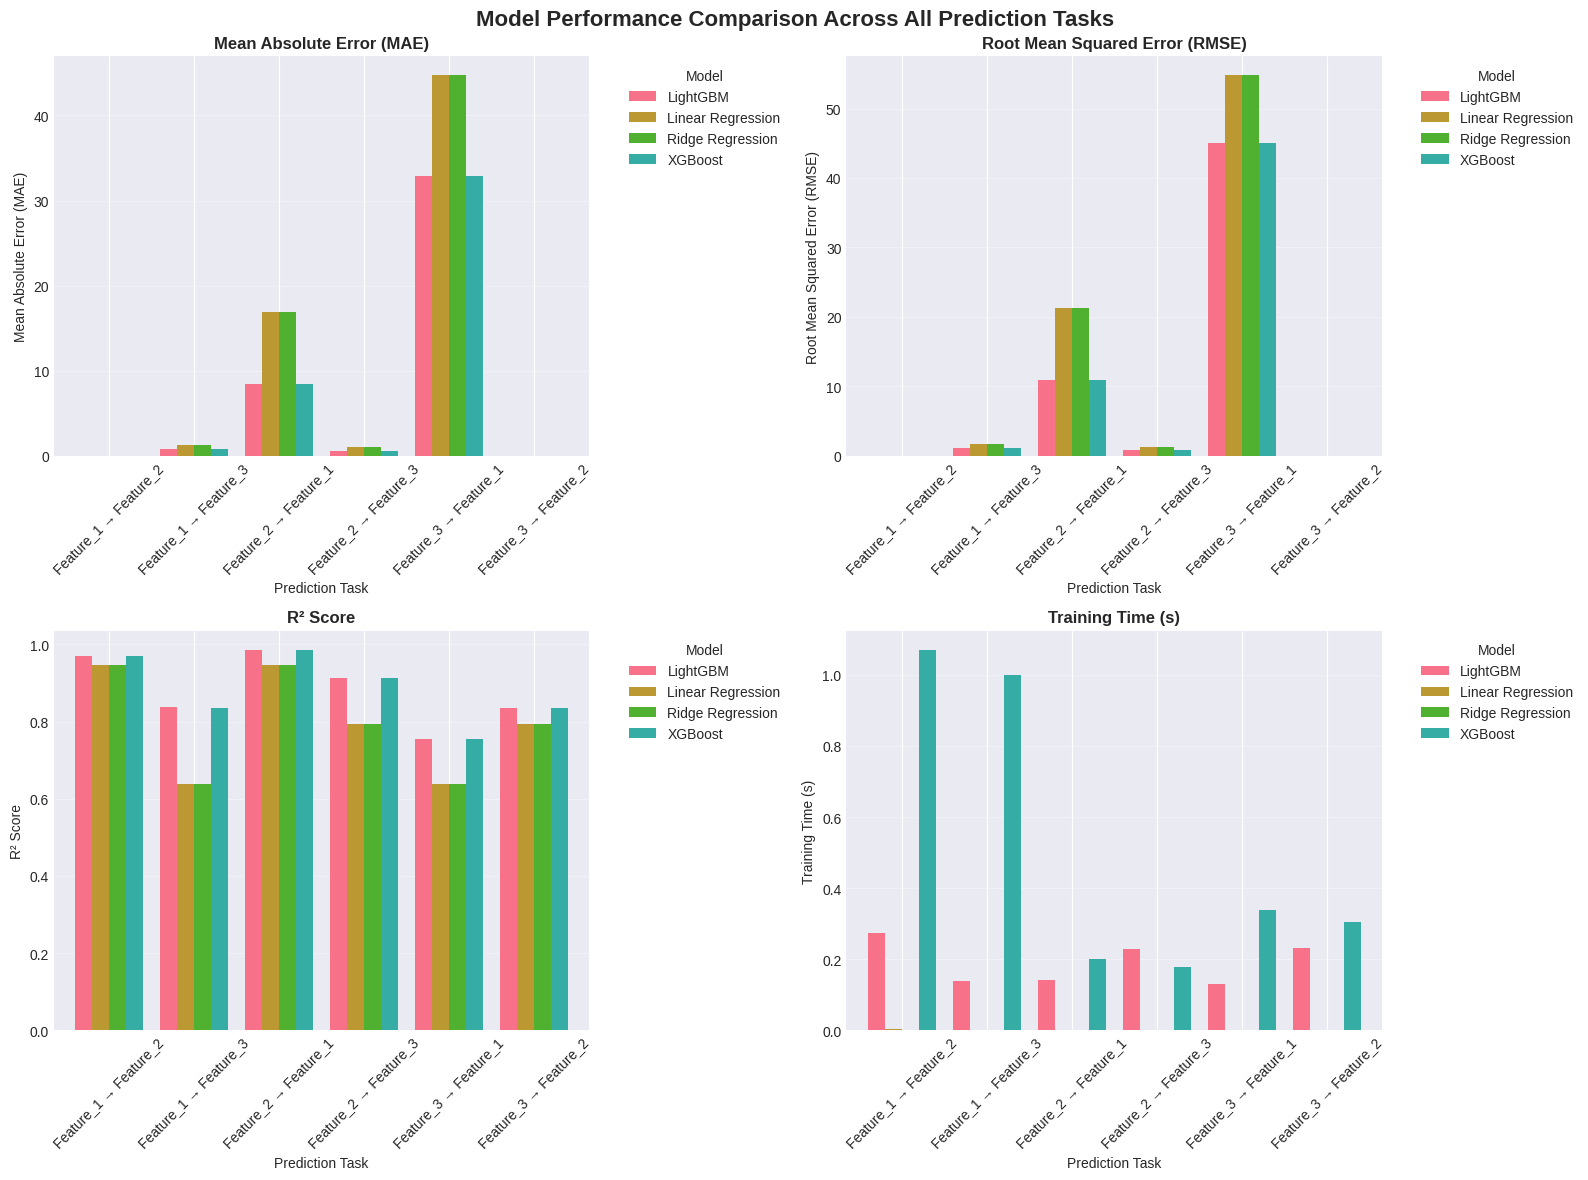

Figure saved to: /home/jatin/contrast/ST-SSL/notebook/ml_results_pems08/model_comparison.png


In [23]:
# Visualize model comparison
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Model Performance Comparison Across All Prediction Tasks', fontsize=16, fontweight='bold')

metrics = ['MAE', 'RMSE', 'R2', 'Train_Time']
metric_names = ['Mean Absolute Error (MAE)', 'Root Mean Squared Error (RMSE)', 'R² Score', 'Training Time (s)']

for idx, (metric, metric_name) in enumerate(zip(metrics, metric_names)):
    ax = axes[idx // 2, idx % 2]
    
    pivot_data = results_df.pivot(index='Pair', columns='Model', values=metric)
    pivot_data.plot(kind='bar', ax=ax, width=0.8)
    
    ax.set_title(metric_name, fontsize=12, fontweight='bold')
    ax.set_xlabel('Prediction Task', fontsize=10)
    ax.set_ylabel(metric_name, fontsize=10)
    ax.legend(title='Model', bbox_to_anchor=(1.05, 1), loc='upper left')
    ax.grid(True, alpha=0.3, axis='y')
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig(os.path.join(results_dir, 'model_comparison.png'), dpi=300, bbox_inches='tight')
plt.show()
print(f"Figure saved to: {os.path.join(results_dir, 'model_comparison.png')}")

## 7. Actual vs Predicted Visualizations

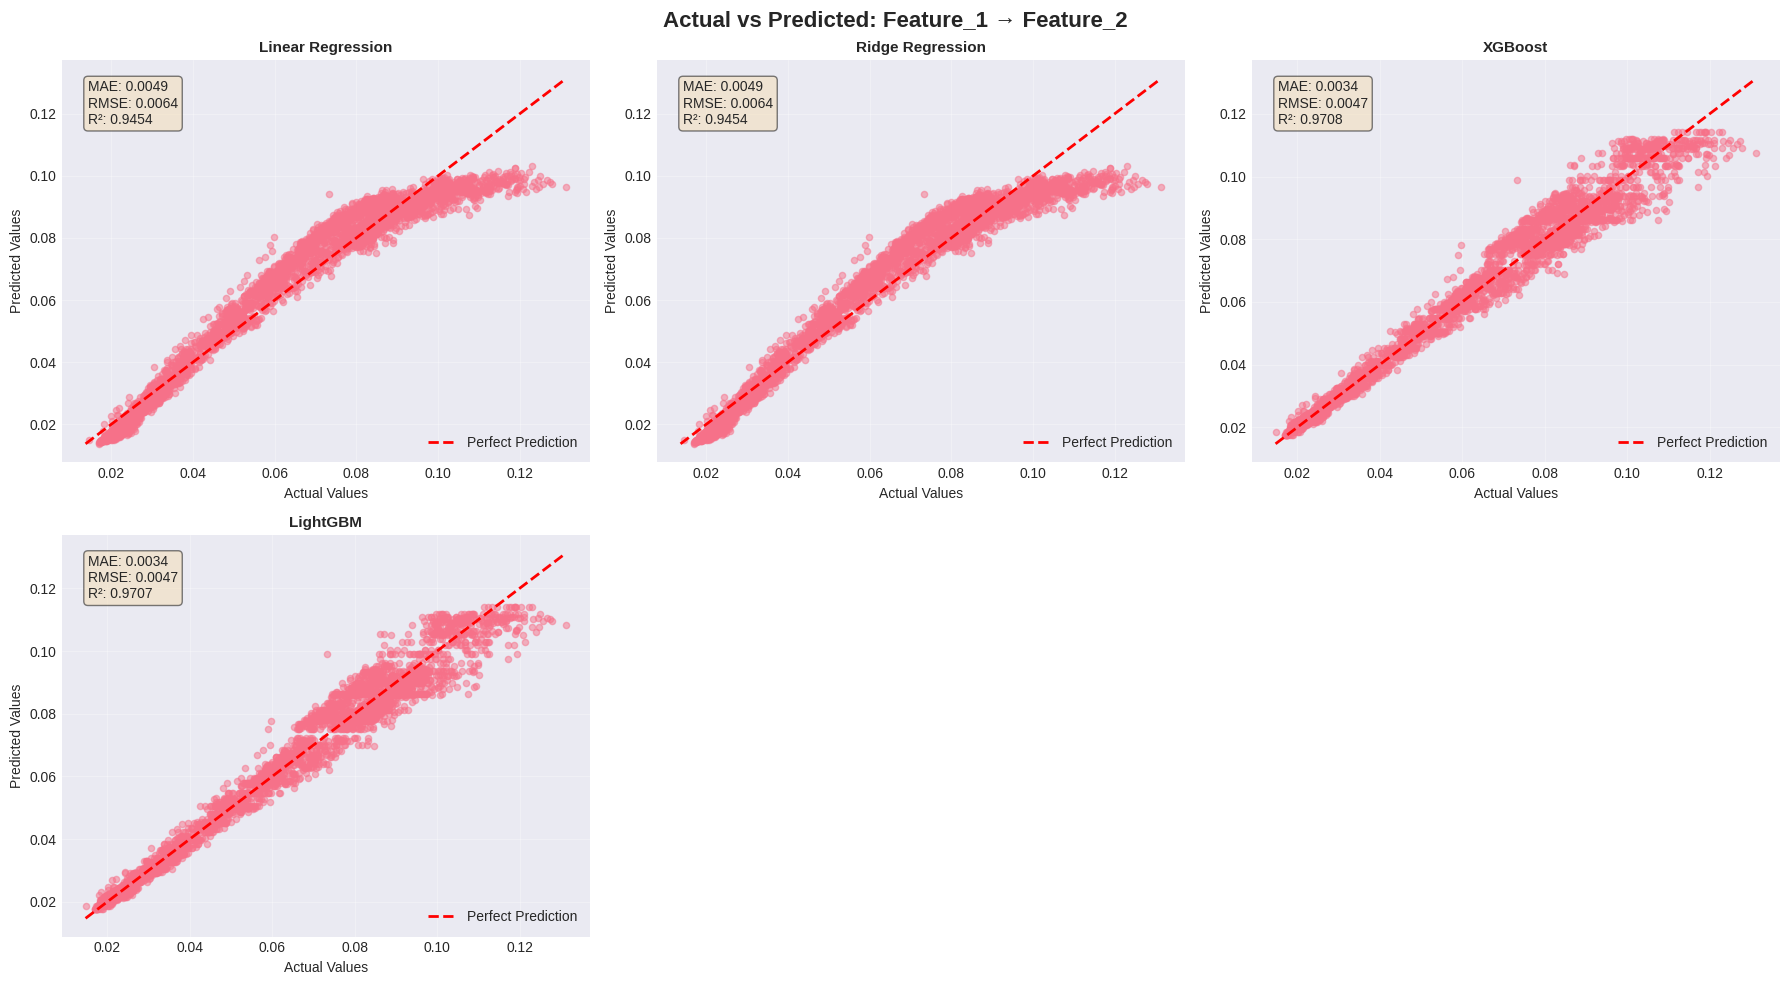

Saved: /home/jatin/contrast/ST-SSL/notebook/ml_results_pems08/actual_vs_predicted_Feature_1_to_Feature_2.png


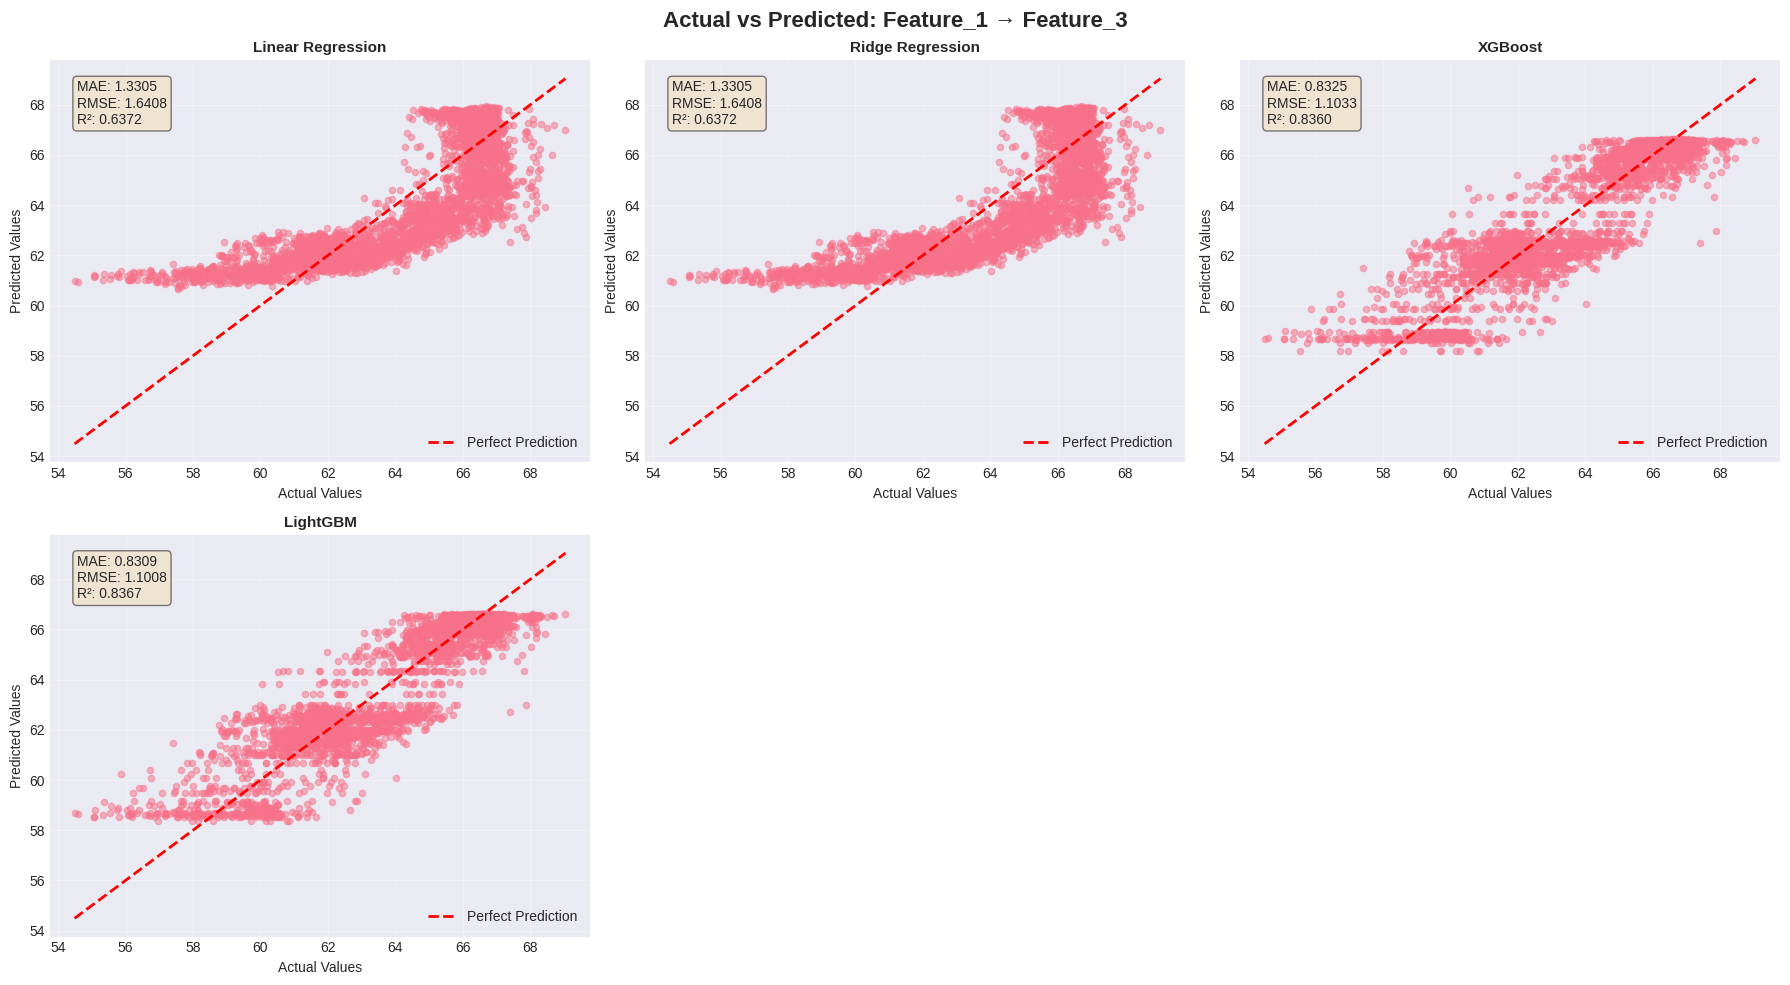

Saved: /home/jatin/contrast/ST-SSL/notebook/ml_results_pems08/actual_vs_predicted_Feature_1_to_Feature_3.png


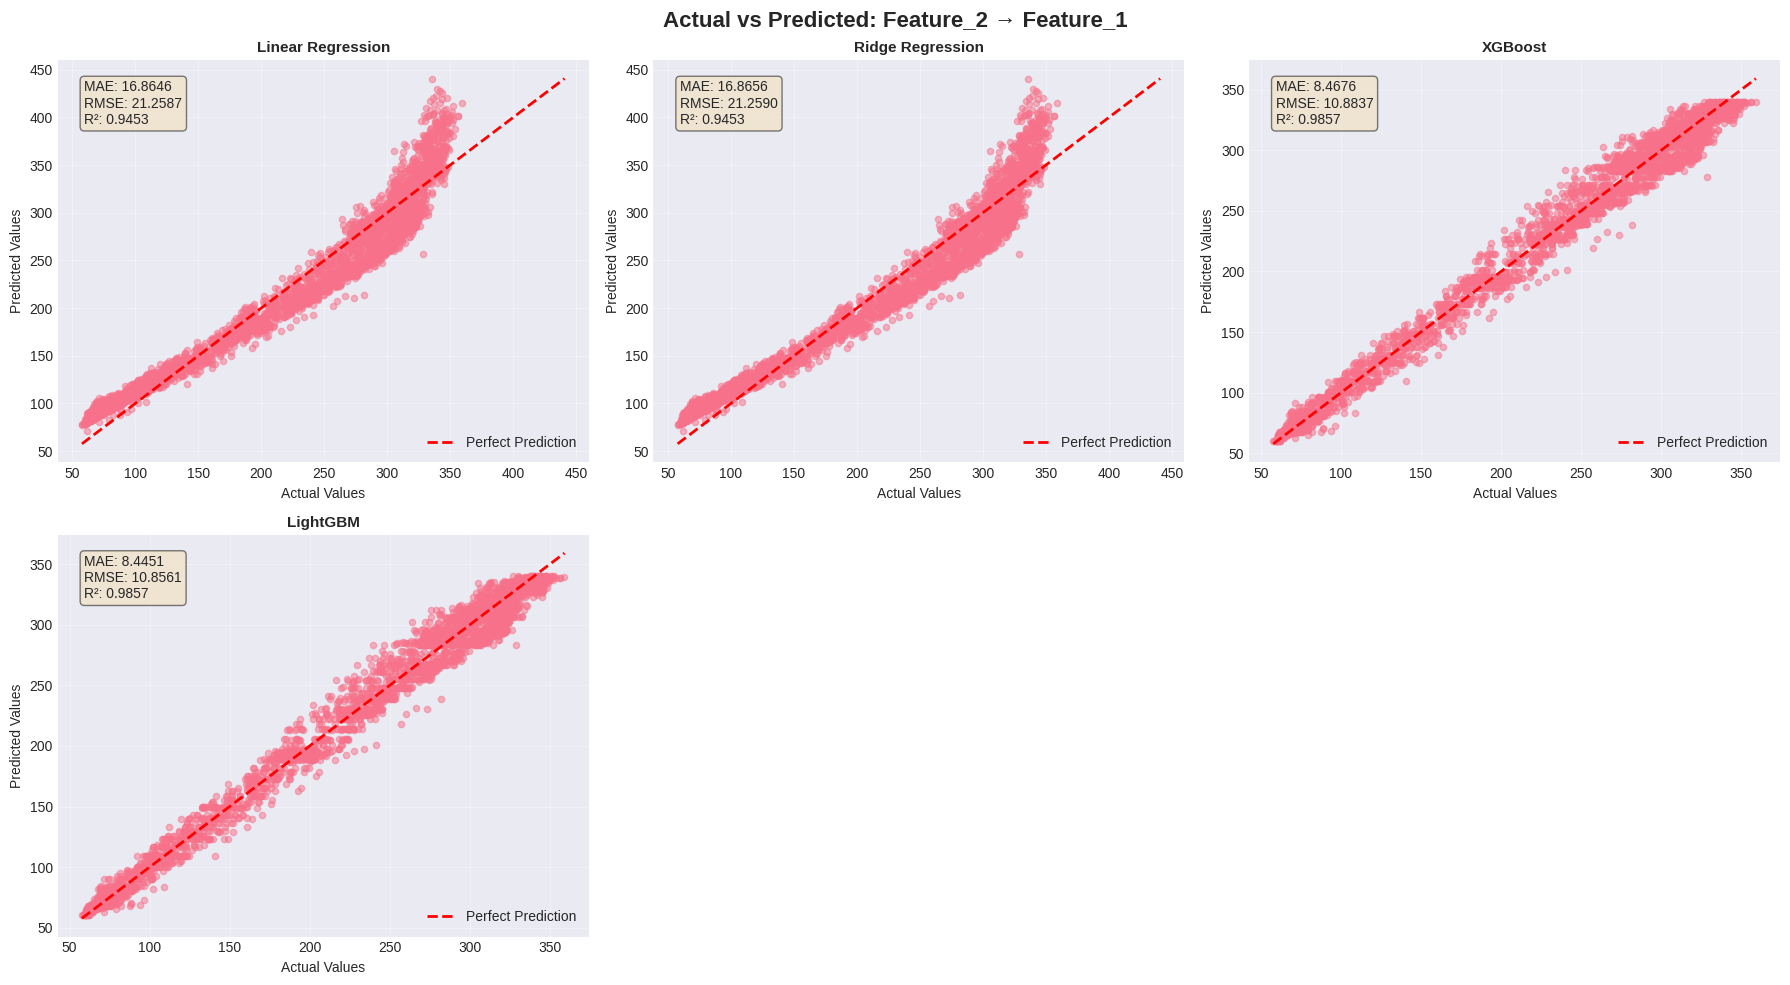

Saved: /home/jatin/contrast/ST-SSL/notebook/ml_results_pems08/actual_vs_predicted_Feature_2_to_Feature_1.png


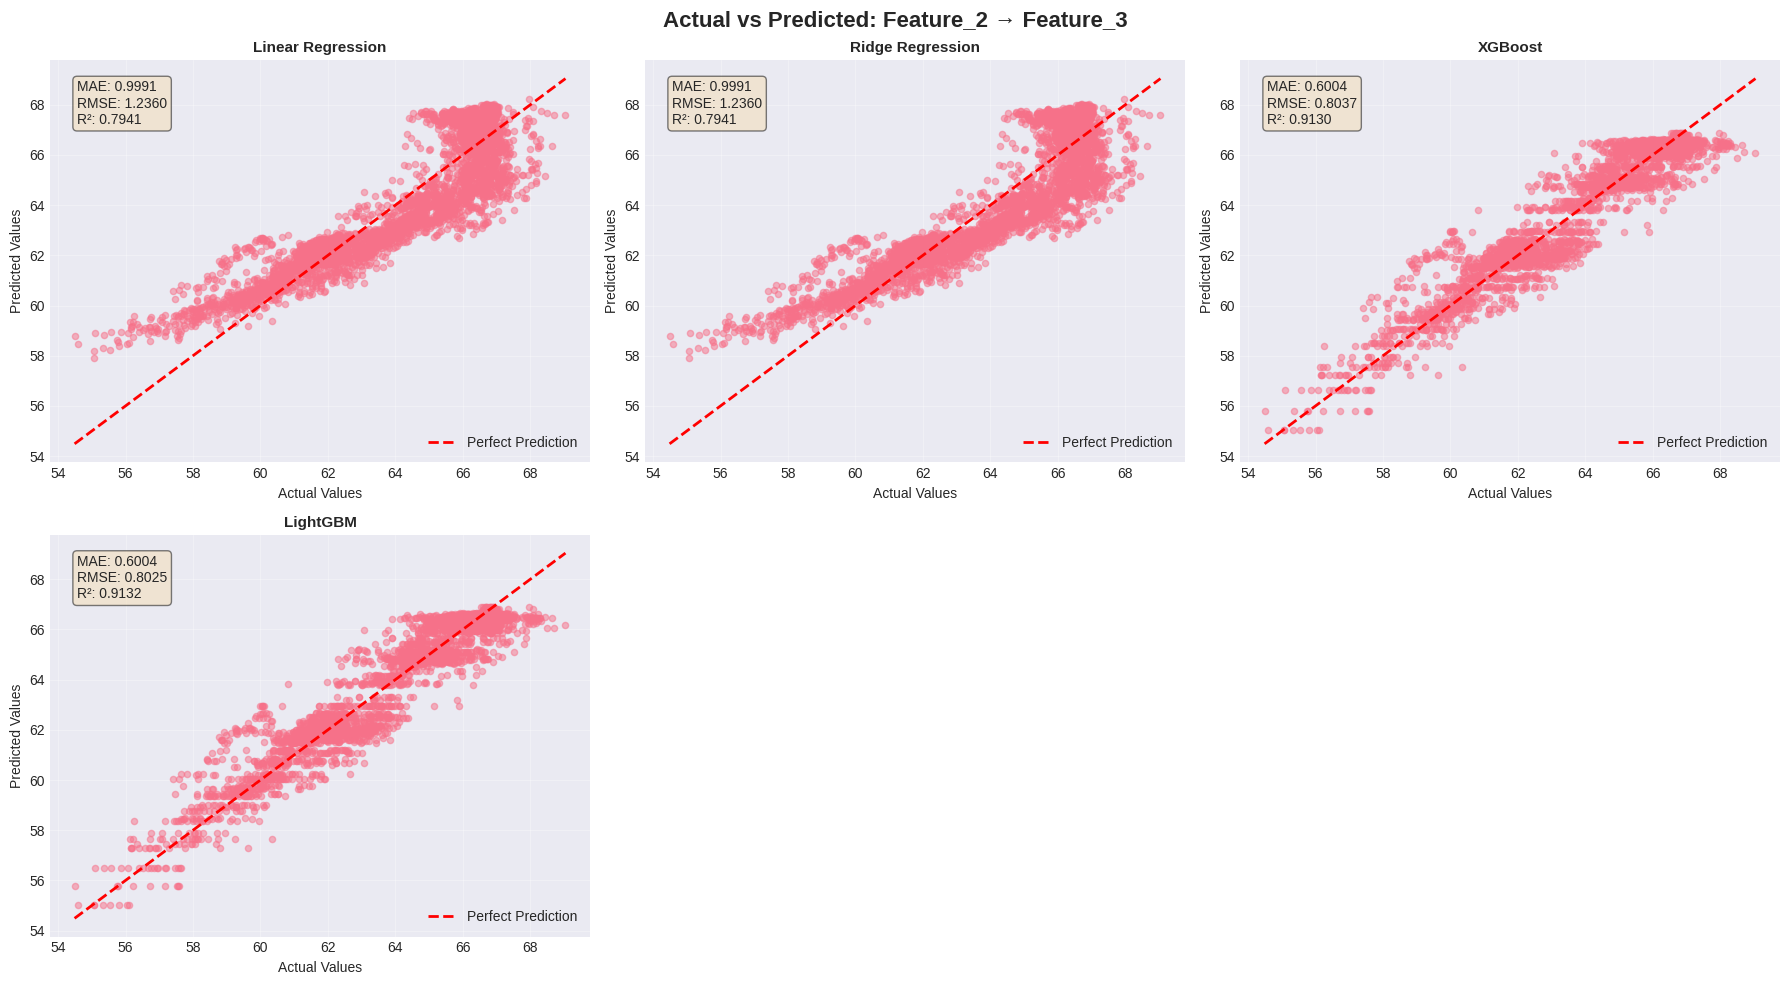

Saved: /home/jatin/contrast/ST-SSL/notebook/ml_results_pems08/actual_vs_predicted_Feature_2_to_Feature_3.png


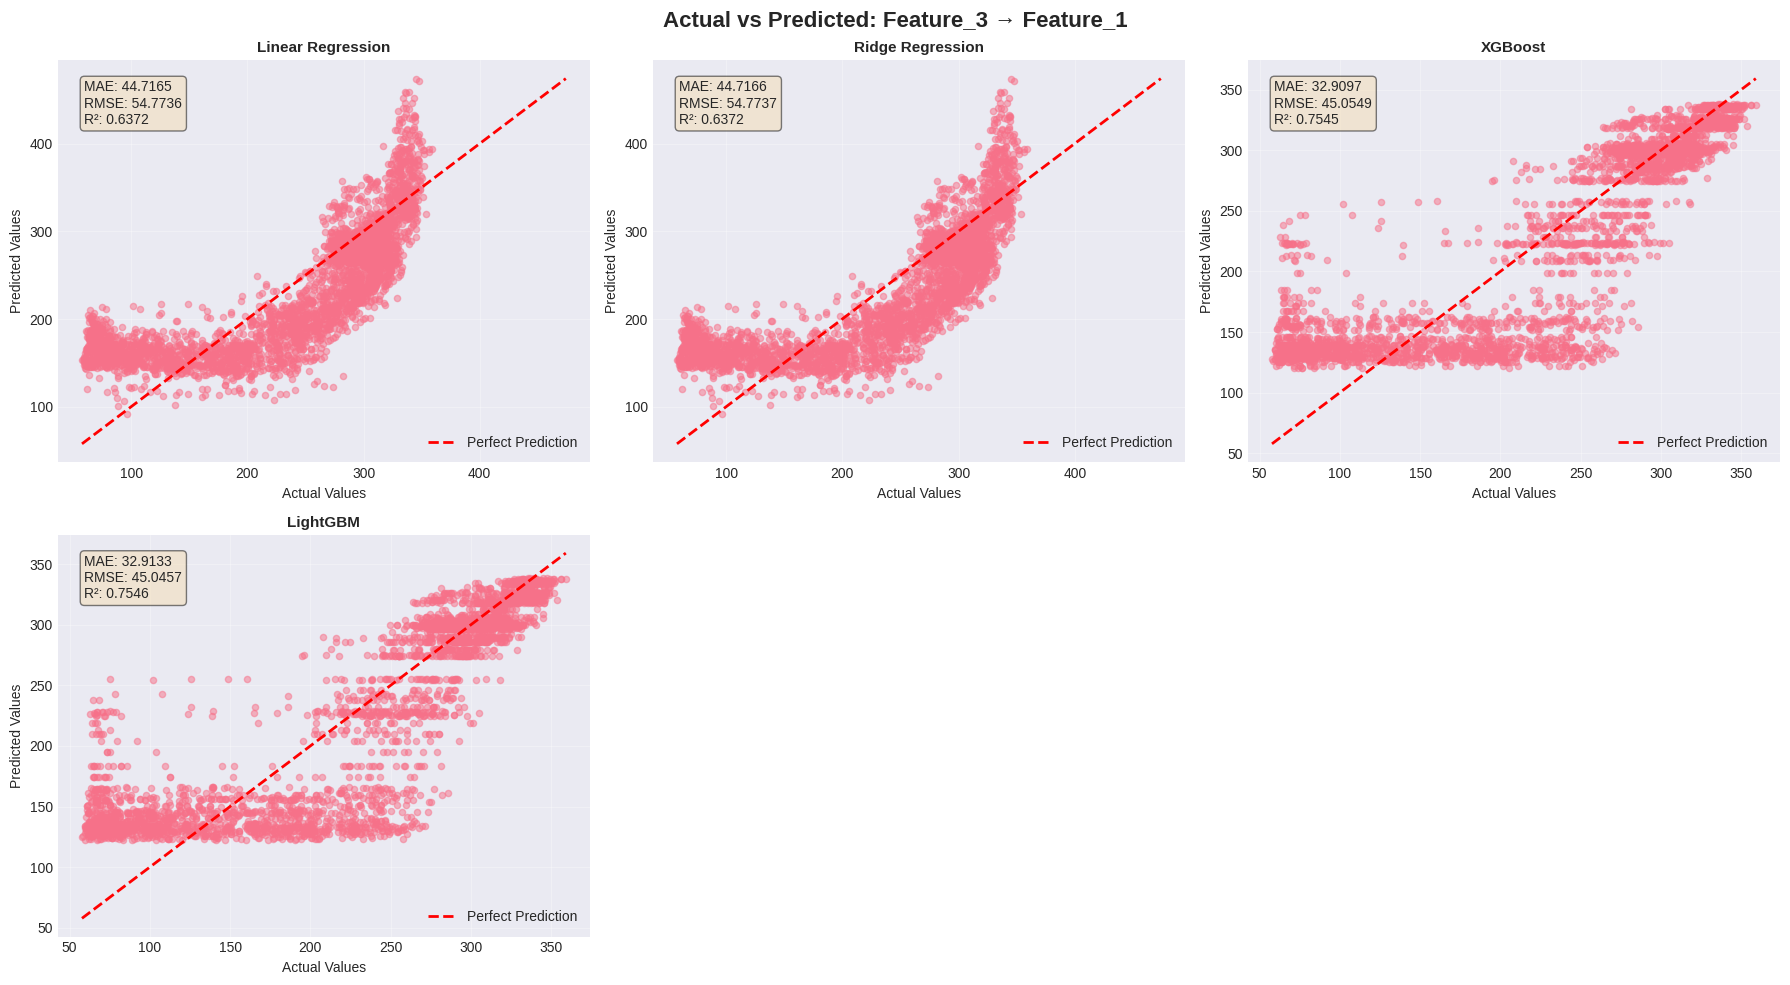

Saved: /home/jatin/contrast/ST-SSL/notebook/ml_results_pems08/actual_vs_predicted_Feature_3_to_Feature_1.png


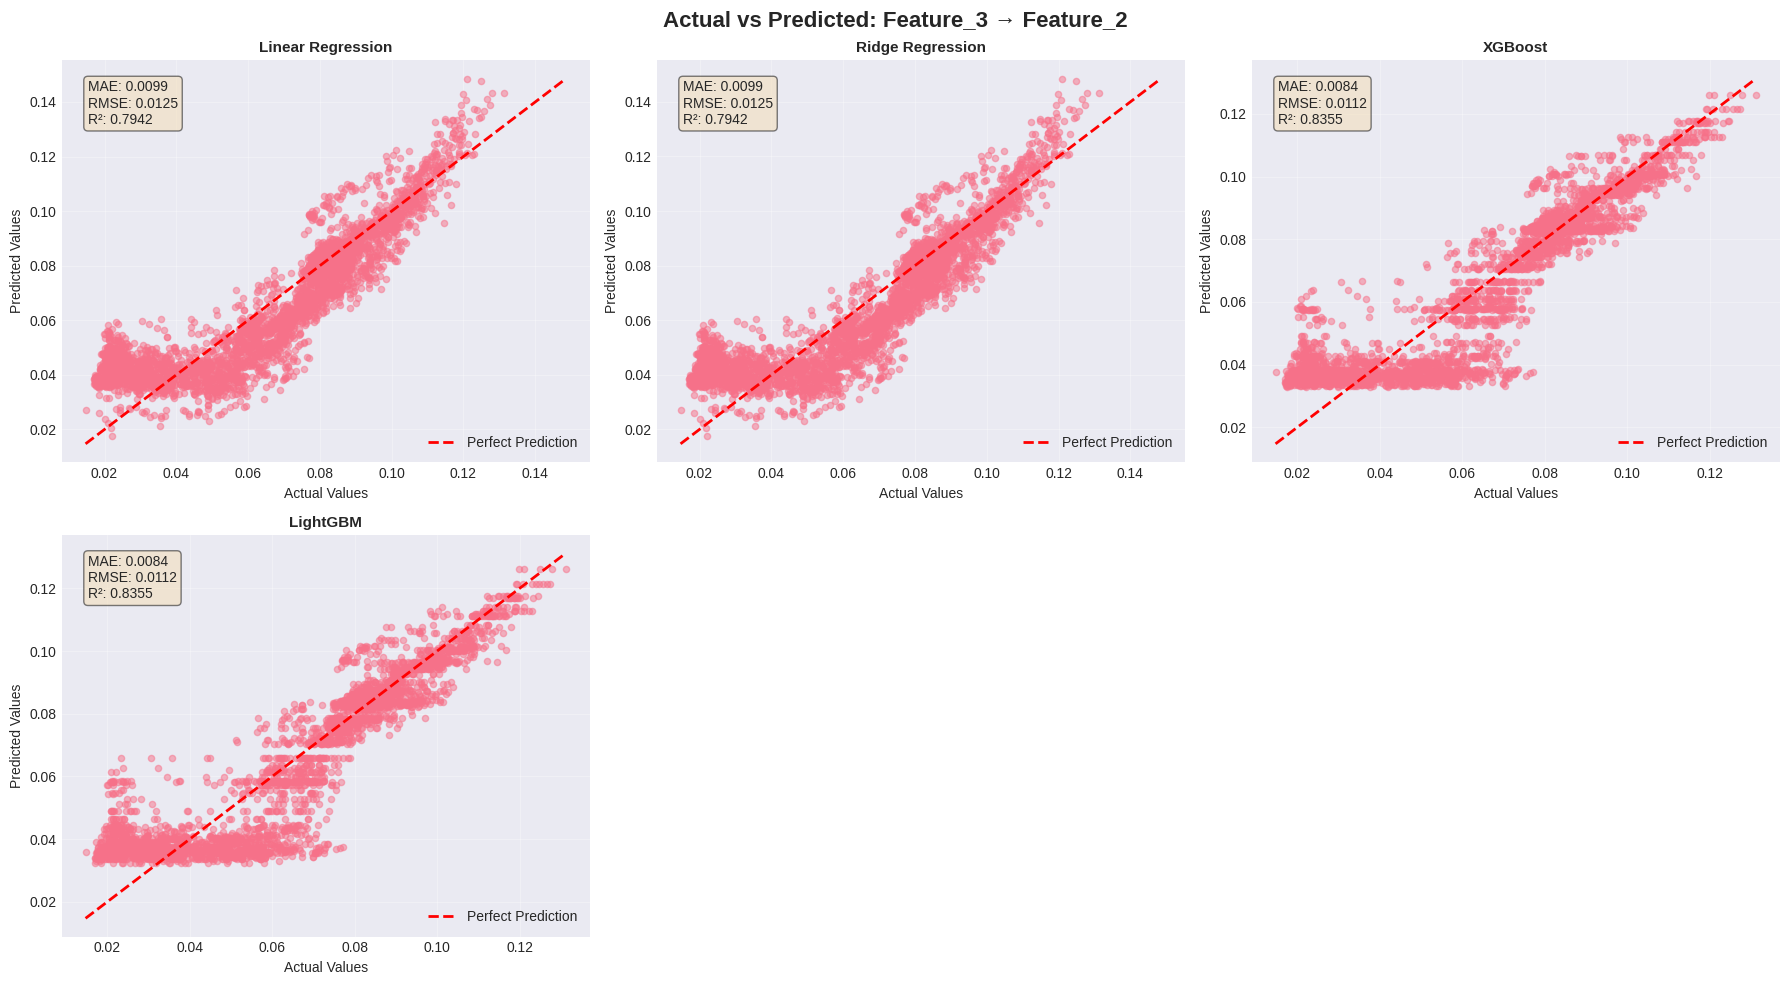

Saved: /home/jatin/contrast/ST-SSL/notebook/ml_results_pems08/actual_vs_predicted_Feature_3_to_Feature_2.png


In [24]:
# Plot actual vs predicted for all pairs and models
for input_feature, output_feature in feature_pairs:
    pair_name = f'{input_feature} → {output_feature}'
    
    # Get all models for this pair
    pair_results = results_df[results_df['Pair'] == pair_name]
    n_models = len(pair_results)
    
    # Create subplots
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    fig.suptitle(f'Actual vs Predicted: {pair_name}', fontsize=16, fontweight='bold')
    axes = axes.flatten()
    
    for idx, (_, row) in enumerate(pair_results.iterrows()):
        model_name = row['Model']
        key = f"{input_feature}_{output_feature}_{model_name}"
        
        if key in predictions_storage:
            pred_data = predictions_storage[key]
            y_test = pred_data['y_test']
            y_pred = pred_data['y_pred']
            
            ax = axes[idx]
            
            # Scatter plot
            ax.scatter(y_test, y_pred, alpha=0.5, s=20)
            
            # Perfect prediction line
            min_val = min(y_test.min(), y_pred.min())
            max_val = max(y_test.max(), y_pred.max())
            ax.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect Prediction')
            
            # Add metrics to plot
            mae = row['MAE']
            rmse = row['RMSE']
            r2 = row['R2']
            
            text_str = f"MAE: {mae:.4f}\nRMSE: {rmse:.4f}\nR²: {r2:.4f}"
            ax.text(0.05, 0.95, text_str, transform=ax.transAxes, 
                   fontsize=10, verticalalignment='top',
                   bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
            
            ax.set_xlabel('Actual Values', fontsize=10)
            ax.set_ylabel('Predicted Values', fontsize=10)
            ax.set_title(f'{model_name}', fontsize=11, fontweight='bold')
            ax.legend(loc='lower right')
            ax.grid(True, alpha=0.3)
    
    # Hide unused subplots
    for idx in range(n_models, len(axes)):
        axes[idx].axis('off')
    
    plt.tight_layout()
    
    # Save figure
    safe_pair_name = pair_name.replace(' → ', '_to_').replace(' ', '_')
    fig_path = os.path.join(results_dir, f'actual_vs_predicted_{safe_pair_name}.png')
    plt.savefig(fig_path, dpi=300, bbox_inches='tight')
    plt.show()
    
    print(f"Saved: {fig_path}")

## 8. Save Models and Provide Prediction Example

We'll save all trained models and show how to load a model and make a prediction.

In [25]:
# Save best models (one best per pair) using joblib
models_dir = os.path.join(results_dir, 'models')
os.makedirs(models_dir, exist_ok=True)

# Build results DataFrame if not already built
results_df = pd.DataFrame(results)

# For each prediction pair, find the best model (highest R2)
best_per_pair = results_df.loc[results_df.groupby('Pair')['R2'].idxmax()]

for _, row in best_per_pair.iterrows():
    pair = row['Pair']
    input_feat = row['Input_Feature']
    output_feat = row['Output_Feature']
    model_name = row['Model']
    pair_key = (input_feat, output_feat)

    model_obj = trained_models.get((input_feat, output_feat, model_name), None)
    scaler_obj = scalers.get(pair_key, None)

    if model_obj is None:
        print(f"Warning: Trained model object not found for {pair} {model_name}. Skipping save.")
        continue

    # Compose filenames
    safe_pair = f"{input_feat}_to_{output_feat}"
    model_file = os.path.join(models_dir, f"{safe_pair}__{model_name.replace(' ', '_')}.joblib")
    scaler_file = os.path.join(models_dir, f"{safe_pair}__{model_name.replace(' ', '_')}_scaler.joblib")

    # Save
    joblib.dump(model_obj, model_file)
    if scaler_obj is not None:
        joblib.dump(scaler_obj, scaler_file)

    print(f"Saved model: {model_file}")
    if scaler_obj is not None:
        print(f"Saved scaler: {scaler_file}")

# Save correlation results
corr_df_path = os.path.join(results_dir, 'correlation_results.csv')
corr_df.to_csv(corr_df_path, index=False)
print(f"Correlation results saved to: {corr_df_path}")

# Example: Load a saved model and make a prediction (example)
print('\nExample usage:')
print('-------------------')
print("# model = joblib.load('<path_to_saved_model>.joblib')")
print("# scaler = joblib.load('<path_to_saved_scaler>.joblib')")
print("# X_new_scaled = scaler.transform(X_new.reshape(-1, 1))")
print("# y_pred = model.predict(X_new_scaled)")


Saved model: /home/jatin/contrast/ST-SSL/notebook/ml_results_pems08/models/Feature_1_to_Feature_2__XGBoost.joblib
Saved scaler: /home/jatin/contrast/ST-SSL/notebook/ml_results_pems08/models/Feature_1_to_Feature_2__XGBoost_scaler.joblib
Saved model: /home/jatin/contrast/ST-SSL/notebook/ml_results_pems08/models/Feature_1_to_Feature_3__LightGBM.joblib
Saved scaler: /home/jatin/contrast/ST-SSL/notebook/ml_results_pems08/models/Feature_1_to_Feature_3__LightGBM_scaler.joblib
Saved model: /home/jatin/contrast/ST-SSL/notebook/ml_results_pems08/models/Feature_2_to_Feature_1__LightGBM.joblib
Saved scaler: /home/jatin/contrast/ST-SSL/notebook/ml_results_pems08/models/Feature_2_to_Feature_1__LightGBM_scaler.joblib
Saved model: /home/jatin/contrast/ST-SSL/notebook/ml_results_pems08/models/Feature_2_to_Feature_3__LightGBM.joblib
Saved scaler: /home/jatin/contrast/ST-SSL/notebook/ml_results_pems08/models/Feature_2_to_Feature_3__LightGBM_scaler.joblib
Saved model: /home/jatin/contrast/ST-SSL/notebook/

## 8. Residual Analysis

---

### Notes and Next Steps

- This notebook uses global averaging across nodes to produce three feature time series; you can modify the approach to use specific nodes or node subsets.
- Consider using TimeSeriesSplit if temporal structure matters more than random splits.
- For larger experiments, add hyperparameter tuning and track runs via MLflow or Weights & Biases.

---

**End of Notebook** 🎯